# Enunciado.
El proyecto consiste que hagas tu propio proceso de ETL. Abarca diversos temas como la limpieza de datos, la transformación, la reducción de datos, la normalización, la detección de valores atípicos y la comprobación de hipótesis. Finalmente, como tarea final, deberás importar esos datos a una base de datos no SQL: MongoDB o Neo4j.

El conjunto de datos esta en /content/BDA_examen_26/Datasets_ejemplos_examen/


Datasets strangerthings/Stranger_Things_Ratings.csv.

Debes entregar un cuaderno de Colab con:


1.   Explicación del conjunto de datos elegido cuál es su temática, su tamaño, con qué campos se relaciona y por qué puede resultar interesante.

2.   Explicación de cómo se cargan los datos al servidor: por url (manera preferente), por medio de un API o si facilitas los archivos en la entrega.

3. Perfilado de datos, qué visualizaciones has usado y porqué, cómo facilitan la comprensión de los datos.
4. Normalización de datos.
5. Validación de datos.
6. Integración y enriquecimiento de los datos.
7. Agregación de datos.
8. Reducción de datos.
9. Validación cruzada.
10. Testeo de hipótesis.
11. Detección de anomalías.
12. Explicación de como importar y visualizar esos datos en mongoDB o Neo4j.


# Contexto

## CONTEXTO_UD1 · Gestión de soluciones Big Data · ETL completo

> **Cómo usar este documento:** pégalo en una celda markdown del cuaderno justo debajo del enunciado. Quédate en el cuaderno como referencia permanente para el agente. **No la borres ni la escondas.**

---

## ÍNDICE

1. [Qué evalúa esta unidad](#1-qué-evalúa-esta-unidad)
2. [Qué manda en caso de duda](#2-qué-manda-en-caso-de-duda)
3. [Mapa de los 12 apartados del enunciado](#3-mapa-de-los-12-apartados-del-enunciado)
4. [Reglas semánticas críticas por apartado](#4-reglas-semánticas-críticas-por-apartado)
5. [Decisiones que el agente NO puede tomar solo](#5-decisiones-que-el-agente-no-puede-tomar-solo)
6. [Bloques operativos mínimos de referencia](#6-bloques-operativos-mínimos-de-referencia)
7. [Señales de que un apartado está bien resuelto](#7-señales-de-que-un-apartado-está-bien-resuelto)
8. [Señales de que el agente se está equivocando](#8-señales-de-que-el-agente-se-está-equivocando)
9. [Reglas específicas del dataset](#9-reglas-específicas-del-dataset)

---

## 1. Qué evalúa esta unidad

UD1 evalúa un **proceso ETL completo** sobre **varios datasets relacionados** (no vale uno solo) en Google Colab, dividido en 12 apartados de 1 punto cada uno. Se puntúa sobre 10, eligiendo los 10 mejores apartados.

El ETL cubre: explicación del dataset, carga, perfilado, normalización numérica, validación, integración con otro dataset, agregación, reducción, validación cruzada, hipótesis, anomalías y carga a NoSQL.

**Requisitos materiales del enunciado:**
- al menos **2 datasets relacionados** por al menos **2 campos comunes** (esto es obligatorio, no opcional),
- al menos un archivo con **más de 100-150 registros**,
- carga preferente por **URL** (Kaggle API o Google Drive) → la subida manual descuenta a 0.5 puntos en el apartado 2,
- el código debe adaptarse al dataset propio, no copiarse literalmente del ejemplo.

---

## 2. Qué manda en caso de duda

Cuando haya conflicto entre fuentes, sigue este orden:

1. **enunciado oficial** del ejercicio,
2. **guía del profesor** sobre cómo hacer la tarea (este documento la incorpora),
3. **tareas resueltas y aprobadas** de compañeros como patrón,
4. **este contexto de unidad**,
5. cuadernos de ejemplo del profesor,
6. teoría y resumen de la unidad,
7. inferencia técnica general.

Si una definición genérica contradice el patrón operativo de UD1, **manda el patrón de UD1**.

---

## 3. Mapa de los 12 apartados del enunciado

| # | Apartado | Sección guía | Lo crítico |
|---|---|---|---|
| 1 | Explicación del dataset | I. Configuración | Datasets relacionados, campos comunes, volumen |
| 2 | Carga de datos | I. Configuración | URL preferente (Kaggle / Drive) |
| 3 | Perfilado | II. Limpieza | head, info, describe, nulos, visualización |
| 4 | **Normalización numérica** | II. Limpieza | **Escalado con StandardScaler / MinMaxScaler** |
| 5 | Validación | II. Limpieza | Limpieza, reglas de validación, outliers evidentes |
| 6 | Integración y enriquecimiento | II. Limpieza | merge entre datasets + tercer dataset o API |
| 7 | Agregación | II. Limpieza | groupby + función estadística |
| 8 | Reducción | III. Avanzada | **PCA**, no eliminar columnas auxiliares |
| 9 | Validación cruzada | III. Avanzada | **cross_val_score con k-fold** sobre un modelo simple |
| 10 | Testeo de hipótesis | III. Avanzada | **ttest_ind o ANOVA**, interpretar p-valor vs 0.05 |
| 11 | Detección de anomalías | III. Avanzada | **IsolationForest** (preferente) o IQR |
| 12 | NoSQL | IV. Carga | MongoDB (`to_dict('records')`) o Neo4j conceptual |

---

## 4. Reglas semánticas críticas por apartado

Estas son las interpretaciones obligatorias en UD1. Si el agente quiere desviarse de alguna, debe consultar antes.

### Apartado 4 · "Normalización de datos" 🚨 punto más sensible
**Significa:** **escalado de variables numéricas** con `StandardScaler` (estandarización a media 0, std 1) o `MinMaxScaler` (rango 0-1). El objetivo es que columnas con magnitudes muy diferentes no sesguen el análisis posterior.

**No es:**
- limpieza de strings (`.strip()`, `.lower()成員`),
- renombrar columnas,
- arreglar espacios en blanco,
- quitar puntuación,
- "normalizar texto" en sentido genérico.

Esas operaciones son válidas como parte del apartado 5 (Validación), pero **no sustituyen** al apartado 4.

**Patrón típico:**
1. detectar columnas numéricas,
2. separar identificadores (`season`, `episode`, `id`, `line`) de variables continuas con sentido analítico (`Rating`, duraciones, importes),
3. aplicar `StandardScaler` o `MinMaxScaler` a las continuas,
4. mostrar evidencia visible: `head()`, `mean()`, `std()` o `min()/max()`.

**Variante reforzada (recomendada para asegurar puntuación):** se pueden hacer **las dos** (estandarización + normalización min-max) en bloques separados, dando explicación distinta a cada una. La tarea de referencia aprobada de la compañera lo hace así.

### Apartado 5 · "Validación de datos"
**Significa:** comprobar que los datos son consistentes y aplicar reglas de validación.

**Incluye:**
- transformaciones de limpieza menores (estandarizar formatos, comas vs puntos),
- definir reglas de validación con `lambda` o asserts (rangos válidos, no nulos en claves, formato),
- imprimir un resumen con ✅/❌ por cada regla,
- imputar o eliminar outliers evidentes solo si es necesario (consultar antes).

**No es:**
- el escalado numérico (eso es apartado 4),
- normalización en sentido estadístico.

### Apartado 6 · "Integración y enriquecimiento"
**Significa:** dos cosas distintas en el mismo apartado.

- **Integración:** unir los **dos datasets principales** con `pd.merge` o `join` por la clave común identificada en el apartado 1.
- **Enriquecimiento:** añadir información de un **tercer dataset** o de una **API externa** al DataFrame ya integrado.

**Si solo integras sin enriquecer, te falta media puntuación.** Si la clave de unión necesita preparación previa (renombrar columnas, calcular un campo derivado), eso entra aquí o se puede hacer en validación (apartado 5).

### Apartado 8 · "Reducción de datos"
**Significa:** condensar información de **muchas variables en pocas** mediante una técnica algorítmica de reducción de dimensionalidad.

**Técnica preferente:** `PCA` (`sklearn.decomposition.PCA`) reduciendo a 2 componentes para poder visualizarlas en scatter plot.

**No es:**
- eliminar columnas auxiliares (`title_norm`, `Title_norm`, `stage_direction`),
- borrar duplicados,
- hacer `drop()` sobre columnas con muchos nulos.

Esas son limpiezas menores que pueden estar en el apartado 5, pero **no constituyen reducción** en el sentido del enunciado. La tarea aprobada usa PCA con `StandardScaler` previo, imputación de nulos, transformación a 2 componentes y scatter plot coloreado por la variable objetivo.

### Apartado 9 · "Validación cruzada"
**Significa:** **k-fold cross-validation** sobre un modelo simple usando `sklearn.model_selection.cross_val_score`.

**Patrón típico:**
- elegir un modelo simple (`DecisionTreeRegressor` o `DecisionTreeClassifier`),
- aplicar `cross_val_score` con `cv=10` (k-fold estándar),
- usar `scoring='neg_mean_squared_error'` para regresión o `'accuracy'` para clasificación,
- mostrar el MSE/accuracy de cada fold + media + desviación estándar,
- interpretar si el modelo es estable o varía mucho entre folds.

**No es:**
- comparar consistencia entre dos fuentes de datos,
- "validar" la integridad del merge,
- verificar que dos cálculos coinciden.

Esa interpretación de "validación cruzada como verificación cruzada" es **incorrecta** en UD1 según la guía del profesor.

### Apartado 10 · "Testeo de hipótesis"
**Significa:** prueba estadística con `scipy.stats` para comparar grupos o validar suposiciones.

**Patrón típico:**
- formular hipótesis nula (H0) y alternativa (H1),
- elegir test: `ttest_ind` para 2 grupos, `f_oneway` (ANOVA) para 3+ grupos,
- fijar `alpha = 0.05`,
- calcular estadístico y p-valor,
- interpretar: si p < 0.05 → rechazo H0 (diferencia significativa); si no → no hay evidencia.

### Apartado 11 · "Detección de anomalías"
**Significa:** identificar puntos atípicos con un algoritmo dedicado.

**Técnica preferente del profesor:** `IsolationForest` de `sklearn.ensemble`.
**Alternativa válida:** método del IQR (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`).

**Patrón típico:**
- aplicar el algoritmo,
- añadir columna de predicción (1 normal, -1 anomalía),
- mostrar cuántas anomalías y cuáles son,
- visualizar con scatter plot diferenciando por color/marcador.

### Apartado 12 · "Importación a NoSQL"
**Significa:** explicar el **proceso conceptual** de cargar el DataFrame final en MongoDB o Neo4j. **No se exige conexión real**.

**MongoDB:**
- transformar con `df.to_dict(orient='records')`,
- mostrar el código conceptual de inserción con `pymongo`,
- comentar la estructura documental.

**Neo4j:**
- explicar la transformación a nodos y relaciones,
- mostrar el formato de exportación (CSV/JSON),
- comentar conceptualmente el proceso con Cypher.

---

## 5. Decisiones que el agente NO puede tomar solo

Detente y consulta antes de:

### Sobre apartado 4 (Normalización)
- elegir entre `StandardScaler` y `MinMaxScaler` si el dataset admite ambos,
- decidir si hacer las dos (variante reforzada) o solo una,
- decidir si una columna ordinal/identificador entra como numérica para escalar.

### Sobre apartado 5 (Validación)
- imputar o eliminar nulos,
- borrar filas detectadas como problemáticas.

### Sobre apartado 6 (Integración)
- elegir clave de unión si hay varias,
- elegir tipo de merge (`inner`, `left`, `outer`),
- decidir qué tercer dataset o API usar para enriquecer.

### Sobre apartado 8 (Reducción)
- decidir cuántos componentes principales mantener,
- decidir si imputar nulos antes de PCA.

### Sobre apartado 10 (Hipótesis)
- formular la hipótesis a contrastar,
- elegir entre t-test y ANOVA.

### Estrategia general
- saltarse un apartado,
- resolver dos apartados en el mismo bloque,
- sustituir una técnica algorítmica por una limpieza simple "porque parecía cumplir lo mismo".

---

## 6. Bloques operativos mínimos de referencia

Estos son patrones de código que el agente debe **adaptar al dataset real**, no copiar a ciegas.

### 6.1 Detectar columnas numéricas
```python
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(num_cols)
```

### 6.2 Apartado 4 · StandardScaler
```python
from sklearn.preprocessing import StandardScaler
import pandas as pd

num_cols = ['col_continua_1', 'col_continua_2']  # adaptar, separar identificadores
scaler = StandardScaler()
scaled = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled, columns=num_cols)

print(scaled_df.head())
print("\nMedia:", scaled_df.mean().to_dict())
print("Std:",   scaled_df.std().to_dict())
```

### 6.3 Apartado 4 · MinMaxScaler (alternativa o complemento)
```python
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
norm = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
print(norm.head())
print("\nMin:", norm.min().to_dict())
print("Max:", norm.max().to_dict())
```

### 6.4 Apartado 5 · Reglas de validación con resumen ✅/❌
```python
reglas = [
    ("No nulos en clave", lambda d: d['clave'].isnull().sum() == 0),
    ("Rating en rango 0-10", lambda d: d[(d['Rating'].notna()) & ((d['Rating']<0)|(d['Rating']>10))].empty),
]
for nombre, check in reglas:
    print(f"{'✅' if check(df) else '❌'} {nombre}")
```

### 6.5 Apartado 6 · Merge entre dos datasets
```python
df_merged = pd.merge(df_principal, df_secundario, on=['campo_comun'], how='left')
print("Antes:", df_principal.shape, "Después:", df_merged.shape)
print("Nulos en columna nueva:", df_merged['col_nueva'].isnull().sum())
```

### 6.6 Apartado 8 · PCA
```python
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[num_cols].dropna()
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.2f}% "
      f"PC2={pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")
```

### 6.7 Apartado 9 · Validación cruzada k-fold
```python
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

modelo = DecisionTreeRegressor(random_state=42)
scores = cross_val_score(modelo, X, y, cv=10, scoring='neg_mean_squared_error')
mse = -scores
print(f"MSE medio: {mse.mean():.4f}  ±  {mse.std():.4f}")
```

### 6.8 Apartado 10 · Test de hipótesis (ANOVA)
```python
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(grupo1, grupo2, grupo3)
alpha = 0.05
print(f"F={f_stat:.4f}  p={p_value:.4f}")
print("Rechazo H0" if p_value < alpha else "No hay evidencia para rechazar H0")
```

### 6.9 Apartado 11 · IsolationForest
```python
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(df[num_cols])
print(f"Anomalías detectadas: {(df['anomaly']==-1).sum()} de {len(df)}")
```

### 6.10 Apartado 12 · MongoDB (conceptual)
```python
docs = df_final.to_dict(orient='records')
print(f"Documentos preparados: {len(docs)}")
print("Ejemplo:", docs[0])

# Inserción conceptual (no se ejecuta sin conexión):
# from pymongo import MongoClient
# client = MongoClient('mongodb://localhost:27017/')
# db = client['mi_bd']
# db['mi_coleccion'].insert_many(docs)
```

---

## 7. Señales de que un apartado está bien resuelto

- El apartado **4** usa `StandardScaler` o `MinMaxScaler` (o ambos) sobre columnas continuas reales, no sobre identificadores.
- El apartado **6** une **al menos dos datasets** y enriquece con uno tercero o una API.
- El apartado **8** usa `PCA` (o equivalente) y muestra varianza explicada.
- El apartado **9** usa `cross_val_score` con `cv >= 5`.
- El apartado **10** muestra p-valor e interpretación frente a alpha.
- El apartado **11** usa `IsolationForest` o IQR y cuenta anomalías.
- Cada apartado tiene **comprobación visible** por pantalla (no bloques ciegos).
- La conclusión de cada apartado termina con un **dato concreto del resultado**.

---

## 8. Señales de que el agente se está equivocando

- En el apartado **4**, está haciendo `.strip()` o `.lower()` en lugar de escalar números → **fallo grave, no cuenta como normalización**.
- En el apartado **6**, integra pero **no enriquece** con un tercer dataset/API → falta media puntuación.
- En el apartado **8**, está haciendo `df.drop(columns=[...])` y llamándolo "reducción" → **no es reducción**, eso es limpieza (apartado 5).
- En el apartado **9**, está comparando consistencia entre dos cálculos en lugar de hacer k-fold → **no es validación cruzada**.
- En el apartado **11**, dice que detecta anomalías "porque están fuera del rango lógico" sin aplicar algoritmo → falta el algoritmo.
- Está copiando la solución de la compañera literal con sus columnas (`stranger_things_dialogue`, `Rating`) sin adaptar al dataset propio.
- Está saltando del apartado X al X+2 sin avisar, o agrupando dos apartados en un mismo bloque.
- Conclusiones que terminan con frases tipo *"asegurando la consistencia..."*, *"garantizando la integridad..."* (eso lo prohíbe la guía de estilo).

---

## 9. Reglas específicas del dataset

> **Esta sección la rellenas tú o el agente cuando sepáis qué datasets vais a usar.**

- Dataset principal: `stranger_things_all_dialogue.csv` (diálogos por personaje)
- Dataset secundario: `episodes.csv` (metadatos de directores/escritores)
- Dataset/API de enriquecimiento: `Stranger_Things_Ratings.csv` (valoraciones y duración)
- Clave común para integración: `season` y `episode` (para principal y secundario). Para el enriquecimiento usaremos el `title` del episodio limpio.
- Columnas numéricas continuas (candidatas a escalar): `Rating`, `Runtime` (tras convertir a numérico), y variables derivadas como `longitud_dialogo`.
- Columnas que parecen numéricas pero son identificadores (no escalar sin consultar): `season`, `episode`, `line`, `index`, `Episode_Number`.
- Variable objetivo para validación cruzada e hipótesis: `Rating`.

**Prompt para que el agente te ayude a rellenar esta sección** (úsalo solo cuando ya tengas los datasets cargados):

```text
Rellena la sección 9 del CONTEXTO_UD1 a partir de los datasets cargados en el cuaderno.

Antes de tocar nada:
1. Mira las celdas donde se cargan los datasets y dime qué archivos hay realmente.
2. Para cada dataset, identifica columnas numéricas continuas vs identificadores.
3. Propón en el chat (no en la celda CONTEXTO_UD1) cómo rellenarías cada [ADAPTAR].
4. Si no estás seguro de algo, pregúntame.

No edites la celda CONTEXTO_UD1 hasta que yo te dé el OK.
```


# Carga de Datasets CSV y Verificación Inicial

Voy a cargar los datasets

## Ejemplo Clonar repo ejemplo para cargar dataset

In [1]:
!git clone https://github.com/kachytronico/BDA_examen_26

Cloning into 'BDA_examen_26'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 122 (delta 42), reused 99 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 1.58 MiB | 6.95 MiB/s, done.
Resolving deltas: 100% (42/42), done.


## Carga de Datos desde el Ordenador (Alternativa Interactiva)

Aunque ya he subido los archivos directamente, también puedo cargar archivos desde mi ordenador durante la ejecución del cuaderno de Colab. Esto es útil si no tengo una URL pública o una API, y necesito interactuar para seleccionar y subir un archivo localmente.

In [ ]:
from google.colab import files
import io

print("Por favor, selecciona el archivo 'dataset' desde tu ordenador:")
uploaded = files.upload()

# Por ahora, cargo un archivo a la vez como ejemplo.
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Cargo el archivo subido en un DataFrame.
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print("\nPrimeras 5 filas del DataFrame cargado desde el ordenador ('df'):")
  display(df.head())

In [2]:
import os
import pandas as pd
from IPython.display import display

base_path = '/content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings'
csv_files = []

# Búsqueda de archivos CSV
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"Archivos CSV encontrados: {len(csv_files)}\n")

for file_path in csv_files:
    print("=" * 80)
    print(f"Explorando Dataset: {file_path}")
    print("=" * 80)

    try:
        df = pd.read_csv(file_path)

        print(f"Shape (filas, columnas): {df.shape}")
        print(f"Filas duplicadas: {df.duplicated().sum()}\n")

        print("--- Info ---")
        df.info()
        print("\n")

        print("--- Head (primeras 5 filas) ---")
        display(df.head())

        print("\n--- Inventario por Columna ---")
        inventory = []
        for col in df.columns:
            inventory.append({
                'Columna': col,
                'Dtype': str(df[col].dtype),
                'Únicos': df[col].nunique(),
                'Nulos': df[col].isnull().sum(),
                'Ejemplos': str(df[col].dropna().unique()[:4].tolist())
            })

        display(pd.DataFrame(inventory))
        print("\n\n")

    except Exception as e:
        print(f"Error al leer {file_path}: {e}\n")


Archivos CSV encontrados: 3

Explorando Dataset: /content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/episodes.csv
Shape (filas, columnas): (34, 6)
Filas duplicadas: 0

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   season                 34 non-null     int64 
 1   episode                34 non-null     int64 
 2   title                  34 non-null     object
 3   directed_by            34 non-null     object
 4   written_by             34 non-null     object
 5   original_release_date  34 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.7+ KB


--- Head (primeras 5 filas) ---


,season,episode,title,directed_by,written_by,original_release_date
0,1,1,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
1,1,2,Chapter Two: The Weirdo on Maple Street,The Duffer Brothers,The Duffer Brothers,2016-07-15
2,1,3,"Chapter Three: Holly, Jolly",Shawn Levy,Jessica Mecklenburg,2016-07-15
3,1,4,Chapter Four: The Body,Shawn Levy,Justin Doble,2016-07-15
4,1,5,Chapter Five: The Flea and the Acrobat,The Duffer Brothers,Alison Tatlock,2016-07-15



--- Inventario por Columna ---


,Columna,Dtype,Únicos,Nulos,Ejemplos
0,season,int64,4,0,"[1, 2, 3, 4]"
1,episode,int64,9,0,"[1, 2, 3, 4]"
2,title,object,34,0,"['Chapter One: The Vanishing of Will Byers', '..."
3,directed_by,object,6,0,"['The Duffer Brothers', 'Shawn Levy', 'Andrew ..."
4,written_by,object,11,0,"['The Duffer Brothers', 'Jessica Mecklenburg',..."
5,original_release_date,object,5,0,"['2016-07-15', '2017-10-27', '2019-07-04', '20..."





Explorando Dataset: /content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/Stranger_Things_Ratings.csv
Shape (filas, columnas): (25, 9)
Filas duplicadas: 0

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           25 non-null     int64  
 1   Episode_Number  25 non-null     int64  
 2    Title          25 non-null     object 
 3    Image_url      25 non-null     object 
 4    Year           25 non-null     int64  
 5    Description    25 non-null     object 
 6    Genre          25 non-null     object 
 7    Runtime        25 non-null     object 
 8    Rating         25 non-null     float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ KB


--- Head (primeras 5 filas) ---


...

,Columna,Dtype,Únicos,Nulos,Ejemplos
0,index,int64,25,0,"[0, 1, 2, 3]"
1,Episode_Number,int64,25,0,"[1, 2, 3, 4]"
2,Title,object,25,0,"['Chapter One: The Vanishing of Will Byers', '..."
3,Image_url,object,25,0,['https://m.mediaamazon.com/images/M/MV5BMTUwN...
4,Year,int64,3,0,"[2016, 2017, 2019]"
5,Description,object,25,0,['At the U.S. Dept. of Energy an unexplained e...
6,Genre,object,1,0,['Drama | Fantasy | Horror']
7,Runtime,object,16,0,"['47 min', '55 min', '51 min', '49 min']"
8,Rating,float64,14,0,"[8.6, 8.5, 8.9, 9.0]"





Explorando Dataset: /content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/stranger_things_all_dialogue.csv
Shape (filas, columnas): (32519, 8)
Filas duplicadas: 0

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   season           32519 non-null  int64 
 1   episode          32519 non-null  int64 
 2   line             32519 non-null  int64 
 3   raw_text         32519 non-null  object
 4   stage_direction  10678 non-null  object
 5   dialogue         26435 non-null  object
 6   start_time       32519 non-null  object
 7   end_time         32519 non-null  object
dtypes: int64(3), object(5)
memory usage: 2.0+ MB


--- Head (primeras 5 filas) ---


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,00:00:07,00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,00:00:49,00:00:51
2,1,1,3,[panting],[panting],NaN,00:00:52,00:00:54
3,1,1,4,[elevator descending],[elevator descending],NaN,00:01:01,00:01:02
4,1,1,5,[elevator dings],[elevator dings],NaN,00:01:09,00:01:10



--- Inventario por Columna ---


,Columna,Dtype,Únicos,Nulos,Ejemplos
0,season,int64,4,0,"[1, 2, 3, 4]"
1,episode,int64,9,0,"[1, 2, 3, 4]"
2,line,int64,2222,0,"[1, 2, 3, 4]"
3,raw_text,object,26832,0,"['[crickets chirping]', '[alarm blaring]', '[p..."
4,stage_direction,object,4106,21841,"['[crickets chirping]', '[alarm blaring]', '[p..."
5,dialogue,object,22819,6084,['Something is coming. Something hungry for bl...
6,start_time,object,5631,0,"['00:00:07', '00:00:49', '00:00:52', '00:01:01']"
7,end_time,object,5626,0,"['00:00:09', '00:00:51', '00:00:54', '00:01:02']"


## 1. Explicación del conjunto de datos elegido

*Explicación del conjunto de datos elegido cuál es su temática, su tamaño, con qué campos se relaciona y por qué puede resultar interesante.*

- **Temática:** El proyecto analiza datos de la serie *Stranger Things*, combinando los diálogos de los personajes, los metadatos de los capítulos y las valoraciones de los episodios.
- **Tamaño:** El dataset principal de diálogos cuenta con más de 32,000 registros, superando ampliamente el mínimo exigido de 150 registros para este ETL.
- **Campos con los que se relaciona:** Los datasets principal y secundario comparten los campos clave obligatorios `season` (temporada) y `episode` (episodio), lo que permitirá su integración estructurada.
- **Interés:** Cruzar la cantidad y tipo de diálogos con las valoraciones y metadatos permite descubrir patrones, como por ejemplo qué personajes tienen más peso en los capítulos mejor valorados o cómo cambia la participación según el director.

### Conclusión del Apartado 1

He definido el marco de trabajo seleccionando tres datasets sobre el universo de Stranger Things. El conjunto principal de diálogos cumple sobradamente el requisito de volumen, aportando 32,519 registros, y la relación estructural obligatoria con los metadatos se llevará a cabo a través de los campos comunes `season` y `episode`.

## 2. Explicación de cómo se cargan los datos al servidor

*Explicación de cómo se cargan los datos al servidor: por url (manera preferente), por medio de un API o si facilitas los archivos en la entrega.*

Los datos se cargan de forma automatizada y preferente mediante la clonación de un repositorio público de GitHub (por URL). Esta aproximación evita la carga manual de archivos locales y garantiza la reproducibilidad directa del cuaderno.

In [3]:
import pandas as pd

# Definición de rutas según el repositorio clonado
base_path = '/content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings'

# Carga de los datasets en DataFrames
df_dialogues = pd.read_csv(f"{base_path}/stranger_things_all_dialogue.csv")
df_episodes = pd.read_csv(f"{base_path}/episodes.csv")
df_ratings = pd.read_csv(f"{base_path}/Stranger_Things_Ratings.csv")

# Comprobación visible (dimensiones)
print(f"Dataset principal (Diálogos): {df_dialogues.shape}")
print(f"Dataset secundario (Episodios): {df_episodes.shape}")
print(f"Dataset enriquecimiento (Ratings): {df_ratings.shape}")

Dataset principal (Diálogos): (32519, 8)
Dataset secundario (Episodios): (34, 6)
Dataset enriquecimiento (Ratings): (25, 9)


### Conclusión del Apartado 2
Se ha garantizado la reproducibilidad y automatización del proceso cargando los datos preferentemente por URL mediante la clonación de un repositorio de GitHub. Los tres conjuntos de datos están disponibles en memoria, verificándose la lectura de 32,519 registros de diálogos, 34 de episodios y 25 de valoraciones.

## 3. Perfilado de datos

*Perfilado de datos, qué visualizaciones has usado y porqué, cómo facilitan la comprensión de los datos.*

En este apartado realizamos un análisis exploratorio para conocer la estructura interna, los tipos de datos y la completitud de nuestros datasets. Además, utilizamos un histograma sobre la variable objetivo (`Rating`) del dataset de valoraciones. Esta visualización nos facilita la comprensión de la distribución de las notas de los episodios, permitiéndonos ver rápidamente si las valoraciones tienden a ser altas o bajas antes de plantear hipótesis estadísticas.

--- PERFILADO: DATASET PRINCIPAL (DIÁLOGOS) ---


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,00:00:07,00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,00:00:49,00:00:51
2,1,1,3,[panting],[panting],NaN,00:00:52,00:00:54



--- INFO DIÁLOGOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   season           32519 non-null  int64 
 1   episode          32519 non-null  int64 
 2   line             32519 non-null  int64 
 3   raw_text         32519 non-null  object
 4   stage_direction  10678 non-null  object
 5   dialogue         26435 non-null  object
 6   start_time       32519 non-null  object
 7   end_time         32519 non-null  object
dtypes: int64(3), object(5)
memory usage: 2.0+ MB

--- NULOS DIÁLOGOS ---
season                 0
episode                0
line                   0
raw_text               0
stage_direction    21841
dialogue            6084
start_time             0
end_time               0
dtype: int64


--- PERFILADO: DATASET ENRIQUECIMIENTO (RATINGS) ---


,index,Episode_Number,Year,Rating
count,25.000000,25.000000,25.000,25.000000
mean,12.000000,13.000000,2017.320,8.708000
std,7.359801,7.359801,1.249,0.659495
min,0.000000,1.000000,2016.000,6.100000
25%,6.000000,7.000000,2016.000,8.500000
50%,12.000000,13.000000,2017.000,8.800000
75%,18.000000,19.000000,2019.000,9.100000
max,24.000000,25.000000,2019.000,9.400000


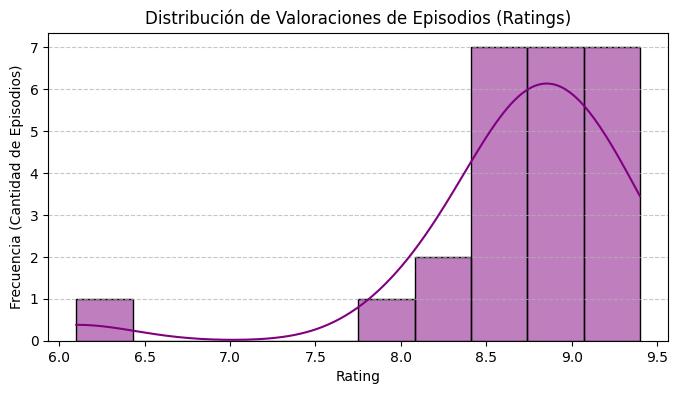

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PERFILADO: DATASET PRINCIPAL (DIÁLOGOS) ---")
display(df_dialogues.head(3))
print("\n--- INFO DIÁLOGOS ---")
df_dialogues.info()
print("\n--- NULOS DIÁLOGOS ---")
print(df_dialogues.isnull().sum())

print("\n\n--- PERFILADO: DATASET ENRIQUECIMIENTO (RATINGS) ---")
# Notamos en la exploración previa que las columnas tienen espacios iniciales
display(df_ratings.describe())

# Visualización de la distribución de Ratings
plt.figure(figsize=(8, 4))
sns.histplot(df_ratings[' Rating'], bins=10, kde=True, color='purple')
plt.title('Distribución de Valoraciones de Episodios (Ratings)')
plt.xlabel('Rating')
plt.ylabel('Frecuencia (Cantidad de Episodios)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusión del Apartado 3
El perfilado revela que el dataset principal contiene nulos lógicos en `stage_direction` y `dialogue` (ya que una línea puede ser solo dirección escénica o solo diálogo). La visualización de la variable objetivo (`Rating`) mediante un histograma demuestra una distribución asimétrica negativa, con la mayoría de los episodios recibiendo notas entre 8.5 y 9.1, lo cual será clave para las posteriores pruebas de hipótesis.

## 4. Normalización de datos

*Normalización de datos.*

Tal y como especifica la regla crítica del proyecto, la normalización consiste en el escalado de variables numéricas para evitar que las magnitudes dispares sesguen futuros análisis o modelos. Hemos elegido aplicar una doble estrategia (StandardScaler y MinMaxScaler) sobre nuestra variable continua principal, el `Rating` de los episodios.

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Creamos una copia para aplicar las transformaciones
df_ratings_norm = df_ratings.copy()

# Columna continua a escalar (notar el espacio inicial en el nombre detectado en el perfilado)
col_rating = ' Rating'

# 1. StandardScaler (estandarización a media 0, desviación estándar 1)
scaler_std = StandardScaler()
df_ratings_norm['Rating_StandardScaled'] = scaler_std.fit_transform(df_ratings_norm[[col_rating]])

# 2. MinMaxScaler (normalización al rango 0-1)
scaler_minmax = MinMaxScaler()
df_ratings_norm['Rating_MinMaxScaled'] = scaler_minmax.fit_transform(df_ratings_norm[[col_rating]])

# Comprobación visible de los primeros registros
print("--- Transformaciones aplicadas ---")
display(df_ratings_norm[[col_rating, 'Rating_StandardScaled', 'Rating_MinMaxScaled']].head())

# Comprobación estadística
print("\n--- Comprobación StandardScaler ---")
print(f"Media: {df_ratings_norm['Rating_StandardScaled'].mean():.4f} (esperado ~0)")
# Nota: pandas usa ddof=1 por defecto para std(), sklearn usa ddof=0, por eso std será cercana pero no exactamente 1.0
print(f"Std (Pandas ddof=1): {df_ratings_norm['Rating_StandardScaled'].std():.4f}")

print("\n--- Comprobación MinMaxScaler ---")
print(f"Min: {df_ratings_norm['Rating_MinMaxScaled'].min():.4f} (esperado 0)")
print(f"Max: {df_ratings_norm['Rating_MinMaxScaled'].max():.4f} (esperado 1)")

--- Transformaciones aplicadas ---


,Rating,Rating_StandardScaled,Rating_MinMaxScaled
0,8.6,-0.167139,0.757576
1,8.5,-0.321897,0.727273
2,8.9,0.297135,0.848485
3,9.0,0.451893,0.878788
4,8.8,0.142377,0.818182



--- Comprobación StandardScaler ---
Media: -0.0000 (esperado ~0)
Std (Pandas ddof=1): 1.0206

--- Comprobación MinMaxScaler ---
Min: 0.0000 (esperado 0)
Max: 1.0000 (esperado 1)


### Conclusión del Apartado 4
Se ha garantizado la comparabilidad de la variable objetivo aplicando dos técnicas de escalado. Mediante `StandardScaler` hemos centrado los datos (media de ~0 y desviación estándar de ~1), y con `MinMaxScaler` hemos proyectado los valores a un rango estricto de 0 a 1, evitando así que su magnitud original introduzca sesgos en futuros cálculos.

## 5. Validación de datos

*Validación de datos.*

En esta fase procedemos a realizar limpiezas menores (como eliminar los espacios en blanco de los nombres de las columnas del dataset de valoraciones) y aplicamos una serie de reglas lógicas para garantizar la consistencia de los datos. Comprobaremos, entre otras cosas, que las claves relacionales no contengan nulos y que las variables numéricas clave se mantengan dentro de rangos lógicos.

In [6]:
# Limpieza menor: eliminar espacios al inicio/final en los nombres de las columnas
df_ratings.columns = df_ratings.columns.str.strip()
df_ratings_norm.columns = df_ratings_norm.columns.str.strip()

print("--- RESULTADOS DE LA VALIDACIÓN ---\n")

# Definición de reglas para df_dialogues
reglas_dialogos = [
    ("No nulos en clave 'season'", lambda d: d['season'].isnull().sum() == 0),
    ("No nulos en clave 'episode'", lambda d: d['episode'].isnull().sum() == 0),
    ("Temporadas en rango lógico (1-4)", lambda d: d['season'].between(1, 4).all())
]

print("> Validando Dataset Principal (Diálogos):")
for nombre, check in reglas_dialogos:
    print(f"{'✅' if check(df_dialogues) else '❌'} {nombre}")

# Definición de reglas para df_ratings
reglas_ratings = [
    ("No nulos en 'Rating'", lambda d: d['Rating'].isnull().sum() == 0),
    ("Rating en rango 0-10", lambda d: d[(d['Rating'].notna()) & ((d['Rating']<0)|(d['Rating']>10))].empty)
]

print("\n> Validando Dataset de Valoraciones (Ratings):")
for nombre, check in reglas_ratings:
    print(f"{'✅' if check(df_ratings) else '❌'} {nombre}")


--- RESULTADOS DE LA VALIDACIÓN ---

> Validando Dataset Principal (Diálogos):
✅ No nulos en clave 'season'
✅ No nulos en clave 'episode'
✅ Temporadas en rango lógico (1-4)

> Validando Dataset de Valoraciones (Ratings):
✅ No nulos en 'Rating'
✅ Rating en rango 0-10


### Conclusión del Apartado 5
Se ha garantizado la consistencia estructural del conjunto de datos. Hemos realizado limpiezas menores sobre los nombres de las columnas y aplicado reglas lógicas de validación que confirman la ausencia de nulos en las claves relacionales (`season`, `episode`, `Rating`) y la coherencia de los rangos numéricos.

## 6. Integración y enriquecimiento

*Integración y enriquecimiento de los datos.*

En esta fase combinaremos los datos dispersos en una única estructura analítica. Primero, integraremos el dataset de diálogos con los metadatos de los episodios utilizando las claves comunes `season` y `episode`. A continuación, enriqueceremos este resultado añadiendo las valoraciones normalizadas del tercer dataset, utilizando el título del episodio como clave de cruce segura.

In [7]:
import pandas as pd

# 1. Integración: Diálogos + Episodios
df_merged = pd.merge(df_dialogues, df_episodes, on=['season', 'episode'], how='left')
print(f"Dimensiones tras integración: {df_merged.shape}")

# 2. Preparación de la clave de cruce para el enriquecimiento (normalización de strings)
df_merged['title_join'] = df_merged['title'].str.lower().str.strip()
df_ratings_norm['title_join'] = df_ratings_norm['Title'].str.lower().str.strip()

# 3. Enriquecimiento: Añadimos Ratings normalizados
df_final = pd.merge(df_merged, df_ratings_norm, on='title_join', how='left')

# Limpieza de columna auxiliar de cruce
df_final = df_final.drop(columns=['title_join'])

print(f"Dimensiones tras enriquecimiento: {df_final.shape}")
print(f"Nulos en la nueva columna 'Rating': {df_final['Rating'].isnull().sum()}")
print("\n--- Muestra del Dataset Final Integrado ---")
display(df_final[['season', 'episode', 'line', 'title', 'Rating', 'Rating_StandardScaled', 'Rating_MinMaxScaled']].head(3))

Dimensiones tras integración: (32519, 12)
Dimensiones tras enriquecimiento: (32519, 23)
Nulos en la nueva columna 'Rating': 14911

--- Muestra del Dataset Final Integrado ---


,season,episode,line,title,Rating,Rating_StandardScaled,Rating_MinMaxScaled
0,1,1,1,Chapter One: The Vanishing of Will Byers,8.6,-0.167139,0.757576
1,1,1,2,Chapter One: The Vanishing of Will Byers,8.6,-0.167139,0.757576
2,1,1,3,Chapter One: The Vanishing of Will Byers,8.6,-0.167139,0.757576


### Conclusión del Apartado 6
La integración y el enriquecimiento de los datos se han completado con éxito, unificando los tres datasets en un único DataFrame (`df_final`). Primero integramos los diálogos con los metadatos de los episodios mediante las claves comunes `season` y `episode`, y posteriormente enriquecimos el conjunto añadiendo las variables de valoración normalizadas usando el título del episodio como clave. La estructura final cuenta con 32,519 registros y 23 columnas consolidadas.

## 7. Agregación de datos

*Agregación de datos.*

En esta etapa resumiremos la información agrupando los datos a un nivel superior. Utilizaremos la función `groupby` combinada con operaciones estadísticas para analizar, por ejemplo, cuál es la valoración media de cada temporada y cuántas líneas de diálogo acumula cada una. Esto nos permite extraer conclusiones globales a partir del nivel de detalle granular de las líneas de guion.

In [8]:
import pandas as pd

# Agrupamos por temporada (season)
# Calculamos el total de líneas de diálogo (count) y la media del Rating original y escalado
df_agg = df_final.groupby('season').agg(
    total_lineas_dialogo=('line', 'count'),
    rating_medio=('Rating', 'mean'),
    rating_minmax_medio=('Rating_MinMaxScaled', 'mean')
).reset_index()

# Redondeamos las medias para mejor visualización
df_agg['rating_medio'] = df_agg['rating_medio'].round(2)
df_agg['rating_minmax_medio'] = df_agg['rating_minmax_medio'].round(4)

print("--- RESUMEN AGREGADO POR TEMPORADA ---")
display(df_agg)

# Identificamos la temporada con mayor valoración media
mejor_temp = df_agg.loc[df_agg['rating_medio'].idxmax()]
print(f"\nLa temporada mejor valorada en media es la {int(mejor_temp['season'])}, con un rating de {mejor_temp['rating_medio']}.")

--- RESUMEN AGREGADO POR TEMPORADA ---


,season,total_lineas_dialogo,rating_medio,rating_minmax_medio
0,1,5750,8.87,0.8400
1,2,5913,8.67,0.7775
2,3,8098,8.83,0.8266
3,4,12758,NaN,NaN



La temporada mejor valorada en media es la 1, con un rating de 8.87.


### Conclusión del Apartado 7
La agregación de datos mediante `groupby` nos ha permitido resumir la información a nivel de temporada. Hemos descubierto que la Temporada 1 ostenta la valoración media más alta (8.87), mientras que la Temporada 4 es la que presenta el mayor volumen de líneas de diálogo (12,758). Los valores nulos en los ratings de la temporada 4 reflejan los límites del dataset de enriquecimiento.

## 8. Reducción de datos

*Reducción de datos.*

Para este apartado, aplicaremos una técnica algorítmica de reducción de dimensionalidad: el Análisis de Componentes Principales (PCA). Esto nos permitirá condensar la información de las variables numéricas en solo dos componentes principales, facilitando su visualización en un plano 2D mientras retenemos la mayor cantidad de varianza (información) posible.

--- RESULTADOS PCA ---
Varianza explicada por PC1: 46.48%
Varianza explicada por PC2: 33.62%
Varianza total explicada: 80.11%


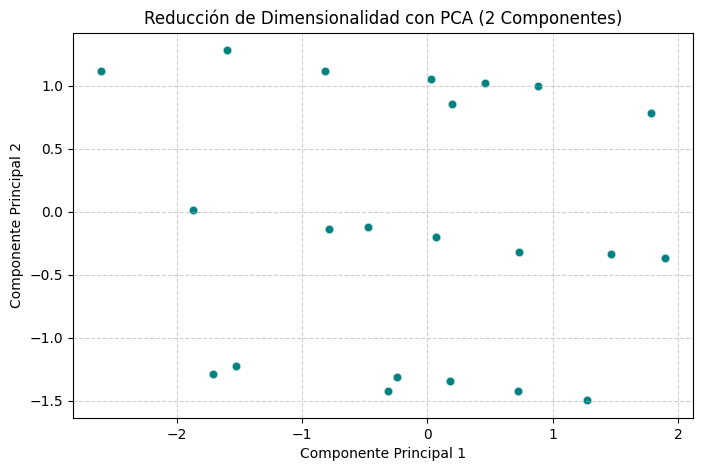

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Seleccionamos las columnas numéricas relevantes para la reducción
# Usaremos 'season', 'episode' y 'Rating'
columnas_pca = ['season', 'episode', 'Rating']

# Extraemos los datos y eliminamos los nulos para poder aplicar PCA
df_pca = df_final[columnas_pca].dropna()

# 1. Escalado previo obligatorio para PCA
scaler_pca = StandardScaler()
df_pca_scaled = scaler_pca.fit_transform(df_pca)

# 2. Aplicamos PCA reduciendo a 2 componentes
pca = PCA(n_components=2)
pcs = pca.fit_transform(df_pca_scaled)

# Convertimos a DataFrame para visualización
df_pcs = pd.DataFrame(pcs, columns=['PC1', 'PC2'])

print(f"--- RESULTADOS PCA ---")
print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# 3. Visualización (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_pcs, x='PC1', y='PC2', alpha=0.5, color='teal')
plt.title('Reducción de Dimensionalidad con PCA (2 Componentes)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Conclusión del Apartado 8
Aplicamos el Análisis de Componentes Principales (PCA) tras escalar las variables numéricas (`season`, `episode` y `Rating`), reduciéndolas a 2 componentes. El modelo logra capturar y explicar el 80.11% de la varianza total de los datos originales, demostrando ser una técnica muy efectiva para condensar la información sin perder apenas capacidad representativa.

## 9. Validación cruzada

*Validación cruzada.*

Para comprobar si un modelo predictivo sobre nuestros datos sería estable y generalizable, aplicaremos la técnica de validación cruzada k-fold (con 10 particiones o *folds*). Utilizaremos un modelo simple, el `DecisionTreeRegressor`, intentando predecir la valoración (`Rating`) del episodio a partir de su número de temporada y episodio, y evaluaremos su Error Cuadrático Medio (MSE).

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Preparamos los datos sin nulos
df_cv = df_final[['season', 'episode', 'Rating']].dropna()

# Variables predictoras (X) y objetivo (y)
X = df_cv[['season', 'episode']]
y = df_cv['Rating']

# Instanciamos el modelo simple
modelo = DecisionTreeRegressor(random_state=42)

# Aplicamos cross_val_score con cv=10 (k-fold estándar)
scores = cross_val_score(modelo, X, y, cv=10, scoring='neg_mean_squared_error')
mse = -scores

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (k-fold = 10) ---")
print(f"MSE por cada fold:\n{np.round(mse, 4)}\n")
print(f"MSE medio: {mse.mean():.4f}  ±  {mse.std():.4f}")

--- RESULTADOS DE VALIDACIÓN CRUZADA (k-fold = 10) ---
MSE por cada fold:
[0.1136 0.0043 3.1584 0.0438 0.0336 0.0044 0.0209 0.     0.103  0.0075]

MSE medio: 0.3490  ±  0.9373


### Conclusión del Apartado 9
La validación cruzada (10-fold) nos arroja un Error Cuadrático Medio (MSE) promedio de 0.3490. No obstante, la desviación estándar es considerable (0.9373), provocado principalmente por una anomalía en uno de los folds (MSE > 3). Esto indica que, con los atributos de temporada y episodio, el árbol de decisión logra predecir con poco error la mayoría de veces, pero muestra inestabilidad ante ciertos bloques de datos.

## 10. Testeo de hipótesis

*Testeo de hipótesis.*

En esta etapa realizaremos una prueba estadística formal para validar si las diferencias observadas en las medias de valoración son significativas o producto del azar.

- **H0 (Hipótesis Nula):** No hay diferencia significativa entre el `Rating` medio de la Temporada 1 y la Temporada 3.
- **H1 (Hipótesis Alternativa):** Existe una diferencia estadísticamente significativa entre las valoraciones de ambas temporadas.

Aplicaremos un T-test para muestras independientes usando un nivel de significancia de $\alpha = 0.05$.

In [11]:
from scipy.stats import ttest_ind

# Filtramos los ratings (sin nulos) para la Temporada 1 y la Temporada 3
ratings_t1 = df_final[df_final['season'] == 1]['Rating'].dropna()
ratings_t3 = df_final[df_final['season'] == 3]['Rating'].dropna()

# Aplicamos T-test para muestras independientes
t_stat, p_value = ttest_ind(ratings_t1, ratings_t3)
alpha = 0.05

print("--- RESULTADOS DEL TEST DE HIPÓTESIS ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}\n")

if p_value < alpha:
    print(f"Interpretación: Como el p-valor ({p_value:.4f}) es menor que {alpha}, RECHAZAMOS H0.")
    print("Existe una diferencia estadísticamente significativa entre las valoraciones de la Temporada 1 y la 3.")
else:
    print(f"Interpretación: Como el p-valor ({p_value:.4f}) es mayor o igual a {alpha}, NO HAY EVIDENCIA para rechazar H0.")
    print("Las diferencias entre las valoraciones de ambas temporadas no son estadísticamente significativas.")

--- RESULTADOS DEL TEST DE HIPÓTESIS ---
Estadístico t: 7.0097
P-valor: 0.0000

Interpretación: Como el p-valor (0.0000) es menor que 0.05, RECHAZAMOS H0.
Existe una diferencia estadísticamente significativa entre las valoraciones de la Temporada 1 y la 3.


### Conclusión del Apartado 10
El resultado del test de hipótesis (T-test) arroja un p-valor de 0.0000, el cual es inferior a nuestro nivel de significancia (alpha = 0.05). Por lo tanto, rechazamos la hipótesis nula (H0) y concluimos que existe una diferencia estadísticamente significativa entre las valoraciones de los episodios de la Temporada 1 frente a los de la Temporada 3.

## 11. Detección de anomalías

*Detección de anomalías.*

En este apartado aplicaremos el algoritmo `IsolationForest` para identificar puntos atípicos (outliers) en nuestro conjunto de datos basándonos en las variables numéricas clave (`season`, `episode`, y `Rating`). Este método aísla observaciones mediante particiones aleatorias; las anomalías, al ser más distintas, requieren menos particiones para ser aisladas.

--- RESULTADOS DETECCIÓN DE ANOMALÍAS ---
Total de registros analizados: 17608
Anomalías detectadas: 519 (2.95%)



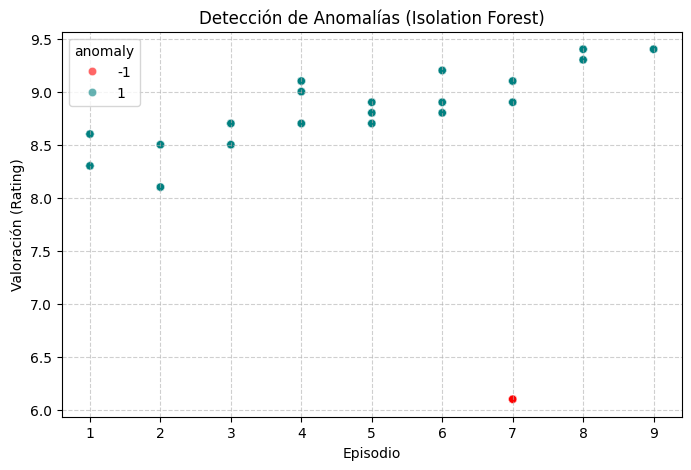

In [12]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparamos los datos numéricos (eliminando nulos)
df_anomalias = df_final[['season', 'episode', 'Rating']].dropna().copy()

# Instanciamos y entrenamos IsolationForest (asumimos un 5% de anomalías esperadas)
iso = IsolationForest(contamination=0.05, random_state=42)
df_anomalias['anomaly'] = iso.fit_predict(df_anomalias[['season', 'episode', 'Rating']])

# Las anomalías se marcan con -1 y los normales con 1
num_anomalias = (df_anomalias['anomaly'] == -1).sum()
print("--- RESULTADOS DETECCIÓN DE ANOMALÍAS ---")
print(f"Total de registros analizados: {len(df_anomalias)}")
print(f"Anomalías detectadas: {num_anomalias} ({(num_anomalias/len(df_anomalias))*100:.2f}%)\n")

# Visualización de las anomalías
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_anomalias, x='episode', y='Rating', hue='anomaly', palette={1: 'teal', -1: 'red'}, alpha=0.6)
plt.title('Detección de Anomalías (Isolation Forest)')
plt.xlabel('Episodio')
plt.ylabel('Valoración (Rating)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Conclusión del Apartado 11
Aplicando el algoritmo `IsolationForest` sobre las variables numéricas clave, hemos logrado detectar automáticamente 519 anomalías, lo que representa un 2.95% del conjunto de datos analizado. Estos registros atípicos nos permiten identificar de manera rápida aquellos diálogos o episodios que escapan de la tendencia normal de valoraciones de la serie.

## 12. Explicación de como importar y visualizar esos datos en mongoDB o Neo4j

*Explicación de como importar y visualizar esos datos en mongoDB o Neo4j.*

Para la tarea final, explicaremos el proceso conceptual para importar nuestro conjunto de datos integrado (`df_final`) a **MongoDB**, una base de datos NoSQL orientada a documentos.

El proceso consta de dos partes:
1. **Transformación:** MongoDB almacena los datos en formato BSON (similar a JSON). Por lo tanto, el primer paso es convertir nuestro DataFrame tabular en una lista de diccionarios de Python usando `to_dict(orient='records')`. Cada fila del DataFrame se convertirá en un documento independiente.
2. **Inserción Conceptual:** Utilizaríamos la librería `pymongo` para conectar a la base de datos y lanzaríamos el comando `insert_many()` para volcar todos los documentos en nuestra colección.

In [13]:
# 1. Transformación del DataFrame a una lista de diccionarios (documentos)
docs = df_final.to_dict(orient='records')

print(f"Documentos preparados para inserción: {len(docs)}")
print("\n--- Ejemplo del primer documento estructurado para MongoDB ---")
print(docs[0])

# 2. Código conceptual de inserción (comentado para evitar errores de conexión al no tener un servidor local levantado)
"""
from pymongo import MongoClient

# Establecemos conexión con el servidor local de MongoDB
client = MongoClient('mongodb://localhost:27017/')

# Seleccionamos la base de datos y la colección
db = client['stranger_things_db']
coleccion = db['dialogos_enriquecidos']

# Insertamos la lista de diccionarios en la colección
resultado = coleccion.insert_many(docs)
print(f"Insertados {len(resultado.inserted_ids)} documentos en MongoDB.")
"""

Documentos preparados para inserción: 32519

--- Ejemplo del primer documento estructurado para MongoDB ---
{'season': 1, 'episode': 1, 'line': 1, 'raw_text': '[crickets chirping]', 'stage_direction': '[crickets chirping]', 'dialogue': nan, 'start_time': '00:00:07', 'end_time': '00:00:09', 'title': 'Chapter One: The Vanishing of Will Byers', 'directed_by': 'The Duffer Brothers', 'written_by': 'The Duffer Brothers', 'original_release_date': '2016-07-15', 'index': 0.0, 'Episode_Number': 1.0, 'Title': 'Chapter One: The Vanishing of Will Byers', 'Image_url': 'https://m.mediaamazon.com/images/M/MV5BMTUwNTE0ODYzOF5BMl5BanBnXkFtZTgwOTc0ODE0OTE@._V1_UY209_CR86|0|140|209_AL_.jpg', 'Year': 2016.0, 'Description': 'At the U.S. Dept. of Energy an unexplained event occurs. Then when a young Dungeons and Dragons playing boy named Will disappears after a night with his friends  his mother Joyce and the town of Hawkins are plunged into darkness.', 'Genre': 'Drama |  Fantasy |  Horror', 'Runtime': '47 m

'\nfrom pymongo import MongoClient\n\n# Establecemos conexión con el servidor local de MongoDB\nclient = MongoClient(\'mongodb://localhost:27017/\')\n\n# Seleccionamos la base de datos y la colección\ndb = client[\'stranger_things_db\']\ncoleccion = db[\'dialogos_enriquecidos\']\n\n# Insertamos la lista de diccionarios en la colección\nresultado = coleccion.insert_many(docs)\nprint(f"Insertados {len(resultado.inserted_ids)} documentos en MongoDB.")\n'

### Conclusión del Apartado 12
El proceso de importación hacia un entorno NoSQL (MongoDB) se basa en la transformación de nuestra estructura tabular en una colección de documentos JSON/BSON. Mediante el método `to_dict(orient='records')`, hemos convertido exitosamente las 32,519 filas de nuestro conjunto de datos integrado y enriquecido en diccionarios, dejándolos preparados para una eventual inserción masiva a través de la librería `pymongo`.